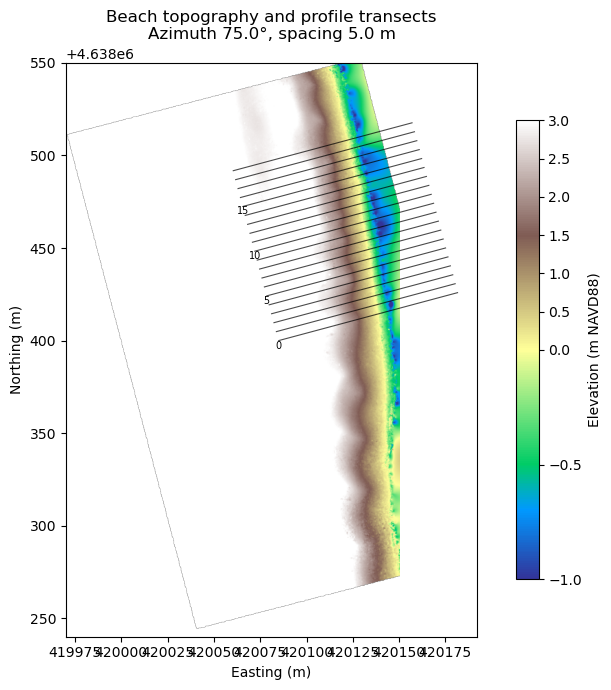

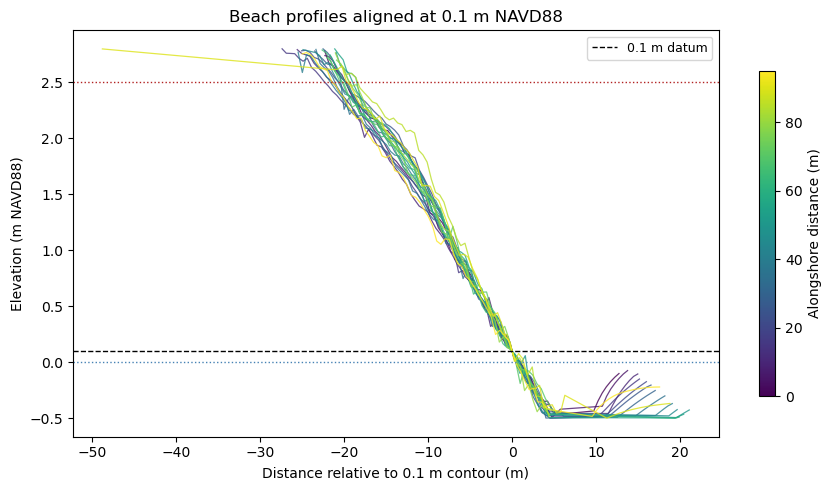

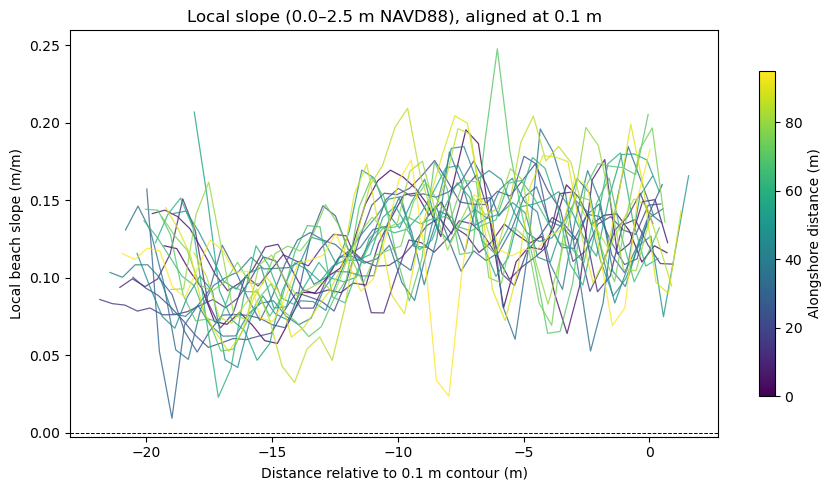

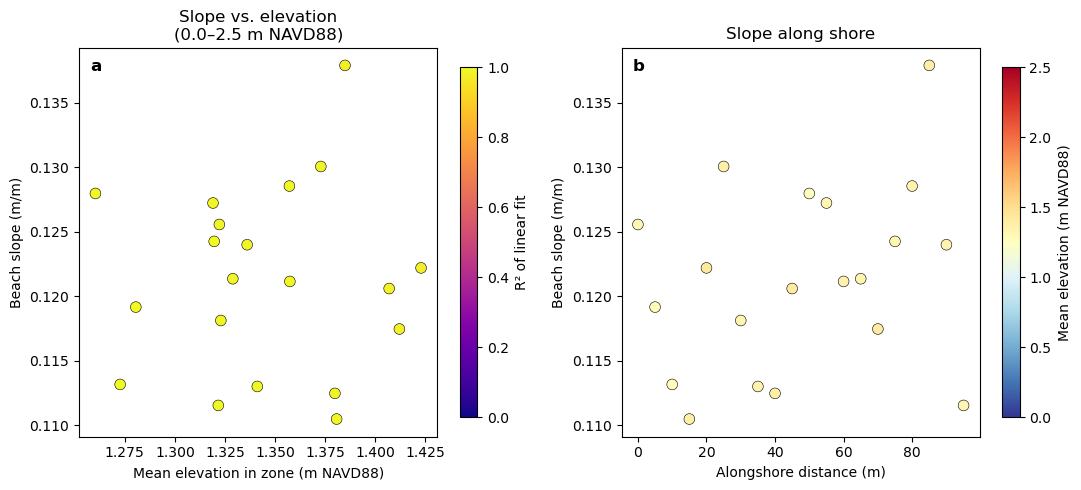


Profiles extracted : 20
Valid slope fits   : 20
Mean slope         : 0.1213 m/m
Std slope          : 0.0070 m/m
Slope range        : 0.1105 – 0.1379 m/m
Mean R²            : 0.989


In [5]:
# csherwood@usgs.gov, 2026-06-05, generated with Claude Sonnet 4.6
# Beach profile extraction from cloud-optimized GeoTIFF
# Extracts profiles at 5-m spacing, oriented 73 deg geographic
# Analyzes beach slopes between 0 and 2.5 m NAVD88

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import rasterio
from rasterio.transform import rowcol
from scipy.ndimage import uniform_filter1d
from scipy.stats import linregress

# ── USER SETTINGS ────────────────────────────────────────────────────────────
COG_DIR  = 'F:/crs/proj/2025_Marconi_maps/Marconi_Products/'
COG_FILE = '2025_Jan_Marconi_DSM_camera_5cm_interp_cog.tif'
COG_PATH = COG_DIR + COG_FILE

# Origin of the profile grid (lon, lat or projected x, y matching the CRS)
ORIGIN_X = 420085.                  # easting of first profile start
ORIGIN_Y = 4638400.                 # northing of first profile start

PROFILE_AZIMUTH = 75.0             # geographic azimuth of profiles (degrees CW from N)
ALONG_SHORE_SPACING = 5.0          # m between profiles
PROFILE_LENGTH = 100.0             # m  – cross-shore length of each profile
SAMPLE_DX = 0.5                    # m  – along-profile sampling interval
SMOOTH_HALF_WIDTH = 0.5            # m  – half-width for cross-profile averaging (0 = off)
N_SMOOTH_SIDE_SAMPLES = 3          # number of sample points on each side for smoothing

ELEV_MIN = 0.0                     # m NAVD88 – lower bound of slope analysis zone
ELEV_MAX = 2.5                     # m NAVD88 – upper bound
DATUM_ELEV = 0.1                   # m NAVD88 – datum for profile alignment
N_PROFILES = 20                    # number of profiles to extract
# ─────────────────────────────────────────────────────────────────────────────


def azimuth_to_unit_vector(az_deg):
    """Geographic azimuth (CW from N) → (dx, dy) unit vector in projected space."""
    az = np.radians(az_deg)
    return np.sin(az), np.cos(az)   # dx (east), dy (north)


def extract_profile(src, x0, y0, dx, dy, length, sample_dx,
                    smooth_half=0.0, n_side=3):
    """
    Sample a DEM along a profile.

    Parameters
    ----------
    src          : open rasterio dataset
    x0, y0       : profile start in dataset CRS
    dx, dy       : unit vector along profile
    length       : profile length (m)
    sample_dx    : along-profile step (m)
    smooth_half  : cross-profile averaging half-width (m); 0 = no smoothing
    n_side       : number of samples on each side for cross-profile average

    Returns
    -------
    dist : 1-D array of along-profile distances
    elev : 1-D array of elevations (NaN where nodata)
    """
    dist = np.arange(0, length + sample_dx, sample_dx)

    # unit vector perpendicular to profile (rotate 90° CCW)
    px, py = -dy, dx

    elevs = []
    for d in dist:
        cx = x0 + d * dx
        cy = y0 + d * dy

        if smooth_half > 0:
            offsets = np.linspace(-smooth_half, smooth_half, 2 * n_side + 1)
            vals = []
            for off in offsets:
                sx, sy = cx + off * px, cy + off * py
                row, col = rowcol(src.transform, sx, sy)
                if 0 <= row < src.height and 0 <= col < src.width:
                    v = src.read(1, window=rasterio.windows.Window(col, row, 1, 1))[0, 0]
                    if v != src.nodata:
                        vals.append(v)
            elevs.append(np.mean(vals) if vals else np.nan)
        else:
            row, col = rowcol(src.transform, cx, cy)
            if 0 <= row < src.height and 0 <= col < src.width:
                v = src.read(1, window=rasterio.windows.Window(col, row, 1, 1))[0, 0]
                elevs.append(v if v != src.nodata else np.nan)
            else:
                elevs.append(np.nan)

    return dist, np.array(elevs, dtype=float)


def datum_distance(dist, elev, datum=0.1):
    """Return the distance along the profile where elevation crosses `datum`."""
    valid = ~np.isnan(elev)
    if valid.sum() < 2:
        return np.nan
    # find first zero-crossing from seaward side (low elevations)
    for i in range(len(elev) - 1):
        if np.isnan(elev[i]) or np.isnan(elev[i+1]):
            continue
        if elev[i] <= datum <= elev[i+1] or elev[i] >= datum >= elev[i+1]:
            frac = (datum - elev[i]) / (elev[i+1] - elev[i])
            return dist[i] + frac * (dist[i+1] - dist[i])
    return np.nan


def profile_slope(dist, elev, elev_min=0.0, elev_max=2.5):
    """
    Linear regression slope (m/m) for the portion of the profile
    between elev_min and elev_max.
    Returns (slope, r2, mean_elev) or (NaN, NaN, NaN).
    """
    mask = (elev >= elev_min) & (elev <= elev_max) & ~np.isnan(elev)
    if mask.sum() < 4:
        return np.nan, np.nan, np.nan
    sl = linregress(dist[mask], elev[mask])
    r2 = sl.rvalue ** 2
    return -sl.slope, r2, np.mean(elev[mask])


# ── MAIN ─────────────────────────────────────────────────────────────────────
dx, dy = azimuth_to_unit_vector(PROFILE_AZIMUTH)

# along-shore direction (perpendicular to profiles)
ax_dir = np.array([-dy, dx])   # (east, north) unit vector along shore

profiles = {}
with rasterio.open(COG_PATH) as src:
    # ── read overview for topo map ──────────────────────────────────────────
    overview_factor = max(1, int(min(src.width, src.height) / 512))
    out_h = max(1, src.height // overview_factor)
    out_w = max(1, src.width  // overview_factor)
    topo = src.read(1, out_shape=(out_h, out_w),
                    resampling=rasterio.enums.Resampling.average).astype(float)
    nodata = src.nodata
    if nodata is not None:
        topo[topo == nodata] = np.nan

    res = src.res[0]  # pixel size (m)
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

    # ── extract profiles ────────────────────────────────────────────────────
    for i in range(N_PROFILES):
        x0 = ORIGIN_X + i * ALONG_SHORE_SPACING * ax_dir[0]
        y0 = ORIGIN_Y + i * ALONG_SHORE_SPACING * ax_dir[1]
        dist, elev = extract_profile(src, x0, y0, dx, dy,
                                     PROFILE_LENGTH, SAMPLE_DX,
                                     smooth_half=SMOOTH_HALF_WIDTH,
                                     n_side=N_SMOOTH_SIDE_SAMPLES)
        d0 = datum_distance(dist, elev, datum=DATUM_ELEV)
        slope, r2, mean_e = profile_slope(dist, elev, ELEV_MIN, ELEV_MAX)
        profiles[i] = dict(x0=x0, y0=y0,
                           dist=dist, elev=elev,
                           d0=d0, slope=slope, r2=r2, mean_elev=mean_e)

# ── FIGURE 1 – topo map with transects ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 7))
cmap_topo = plt.cm.terrain
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=ELEV_MAX + 0.5)
im = ax1.imshow(topo, extent=extent, origin='upper',
                cmap=cmap_topo, norm=norm, interpolation='bilinear')
plt.colorbar(im, ax=ax1, label='Elevation (m NAVD88)', shrink=0.8)
for i, p in profiles.items():
    xe = p['x0'] + PROFILE_LENGTH * dx
    ye = p['y0'] + PROFILE_LENGTH * dy
    ax1.plot([p['x0'], xe], [p['y0'], ye], 'k-', lw=0.8, alpha=0.7)
    if i % 5 == 0:
        ax1.text(p['x0'], p['y0'], str(i), fontsize=7, color='k',
                 ha='center', va='top')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.set_title(f'Beach topography and profile transects\n'
              f'Azimuth {PROFILE_AZIMUTH}°, spacing {ALONG_SHORE_SPACING} m')
ax1.set_aspect('equal')
fig1.tight_layout()
fig1.savefig('fig1_topo_transects.png', dpi=150)

# ── FIGURE 2 – profiles aligned by datum crossing ───────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
cmap_p = plt.cm.viridis
colors = cmap_p(np.linspace(0, 1, N_PROFILES))
for i, p in profiles.items():
    if np.isnan(p['d0']):
        continue
    rel_dist = p['dist'] - p['d0']
    mask = (p['elev'] >= ELEV_MIN - 0.5) & (p['elev'] <= ELEV_MAX + 0.3)
    ax2.plot(rel_dist[mask], p['elev'][mask], color=colors[i], lw=0.9, alpha=0.8)
ax2.axhline(DATUM_ELEV, color='k', ls='--', lw=1, label=f'{DATUM_ELEV} m datum')
ax2.axhline(ELEV_MIN,   color='steelblue', ls=':', lw=1)
ax2.axhline(ELEV_MAX,   color='firebrick', ls=':', lw=1)
ax2.axvspan(0, 1, alpha=0.0)   # placeholder
ax2.set_xlabel(f'Distance relative to {DATUM_ELEV} m contour (m)')
ax2.set_ylabel('Elevation (m NAVD88)')
ax2.set_title(f'Beach profiles aligned at {DATUM_ELEV} m NAVD88')
sm = plt.cm.ScalarMappable(cmap=cmap_p,
     norm=mcolors.Normalize(0, (N_PROFILES-1)*ALONG_SHORE_SPACING))
sm.set_array([])
plt.colorbar(sm, ax=ax2, label='Alongshore distance (m)', shrink=0.8)
ax2.legend(fontsize=9)
fig2.tight_layout()
fig2.savefig('fig2_profiles_aligned.png', dpi=150)

# ── FIGURE 3 – slopes along profiles aligned by datum ───────────────────────
# Compute local (running) slope at each point within the zone
fig3, ax3 = plt.subplots(figsize=(9, 5))
window_pts = max(3, int(1.0 / SAMPLE_DX))   # ~1 m window for local slope
for i, p in profiles.items():
    if np.isnan(p['d0']):
        continue
    rel_dist = p['dist'] - p['d0']
    elev = p['elev']
    # local slope via central difference, then light smoothing
    local_slope = np.gradient(elev, p['dist'])
    local_slope = uniform_filter1d(local_slope, size=window_pts)
    mask = (elev >= ELEV_MIN) & (elev <= ELEV_MAX)
    ax3.plot(rel_dist[mask], -local_slope[mask],
             color=colors[i], lw=0.9, alpha=0.8)
ax3.axhline(0, color='k', lw=0.7, ls='--')
ax3.set_xlabel(f'Distance relative to {DATUM_ELEV} m contour (m)')
ax3.set_ylabel('Local beach slope (m/m)')
ax3.set_title(f'Local slope ({ELEV_MIN}–{ELEV_MAX} m NAVD88), aligned at {DATUM_ELEV} m')
plt.colorbar(sm, ax=ax3, label='Alongshore distance (m)', shrink=0.8)
fig3.tight_layout()
fig3.savefig('fig3_slopes_aligned.png', dpi=150)

# ── FIGURE 4 – scatter: bulk slope v. mean elevation ─────────────────────────
slopes = np.array([p['slope'] for p in profiles.values()])
mean_el = np.array([p['mean_elev'] for p in profiles.values()])
r2s = np.array([p['r2'] for p in profiles.values()])
valid = ~(np.isnan(slopes) | np.isnan(mean_el))

fig4, axes = plt.subplots(1, 2, figsize=(11, 5))

# panel a – slope v. mean elevation
sc = axes[0].scatter(mean_el[valid], slopes[valid],
                     c=r2s[valid], cmap='plasma', vmin=0, vmax=1,
                     s=60, edgecolors='k', linewidths=0.4)
plt.colorbar(sc, ax=axes[0], label='R² of linear fit', shrink=0.9)
axes[0].set_xlabel(f'Mean elevation in zone (m NAVD88)')
axes[0].set_ylabel('Beach slope (m/m)')
axes[0].set_title(f'Slope vs. elevation\n({ELEV_MIN}–{ELEV_MAX} m NAVD88)')
axes[0].text(0.03, 0.97, 'a', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', va='top')

# panel b – slope v. alongshore position
along_pos = np.array([i * ALONG_SHORE_SPACING for i in profiles])
axes[1].scatter(along_pos[valid], slopes[valid],
                c=mean_el[valid], cmap='RdYlBu_r',
                vmin=ELEV_MIN, vmax=ELEV_MAX,
                s=60, edgecolors='k', linewidths=0.4)
sm2 = plt.cm.ScalarMappable(cmap='RdYlBu_r',
      norm=mcolors.Normalize(ELEV_MIN, ELEV_MAX))
sm2.set_array([])
plt.colorbar(sm2, ax=axes[1], label='Mean elevation (m NAVD88)', shrink=0.9)
axes[1].set_xlabel('Alongshore distance (m)')
axes[1].set_ylabel('Beach slope (m/m)')
axes[1].set_title('Slope along shore')
axes[1].text(0.03, 0.97, 'b', transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', va='top')

fig4.tight_layout()
fig4.savefig('fig4_slope_scatter.png', dpi=150)

plt.show()

# ── SUMMARY STATS ─────────────────────────────────────────────────────────────
print(f"\nProfiles extracted : {N_PROFILES}")
print(f"Valid slope fits   : {valid.sum()}")
print(f"Mean slope         : {np.nanmean(slopes):.4f} m/m")
print(f"Std slope          : {np.nanstd(slopes):.4f} m/m")
print(f"Slope range        : {np.nanmin(slopes):.4f} – {np.nanmax(slopes):.4f} m/m")
print(f"Mean R²            : {np.nanmean(r2s):.3f}")


Runup elevation sensitivity  (Δx = 10.0 m,  z₀ = 0.1 m NAVD88)
Case               β (m/m)     η_R (m)      Δη (m)
──────────────────────────────────────────────────
mean                0.1196      1.2962      1.1962
mean + 1σ           0.1535      1.6347      1.5347
mean − 1σ           0.0858      0.9578      0.8578
min                 0.0094      0.1942      0.0942
max                 0.2477      2.5771      2.4771


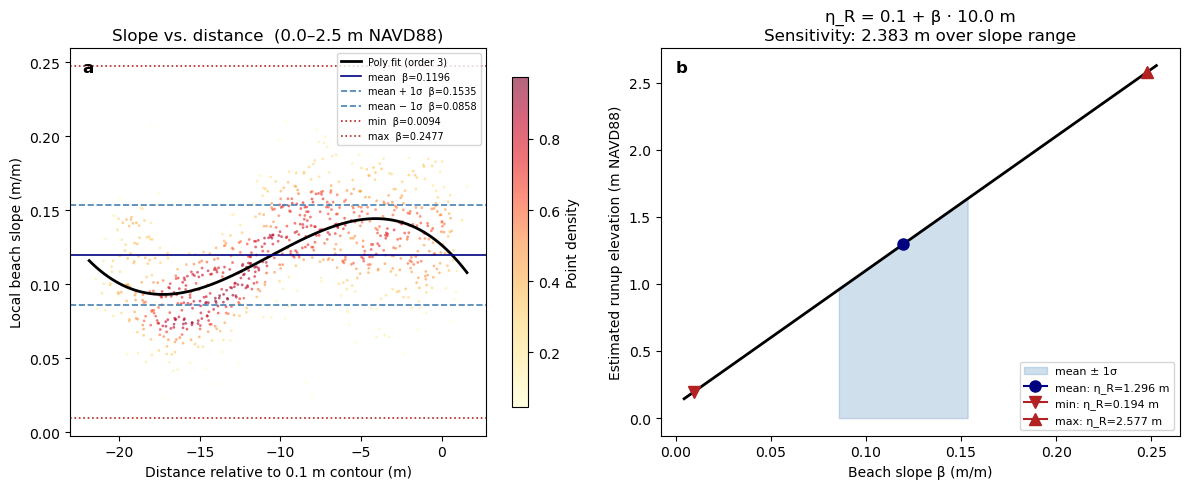


Polynomial fit coefficients (order 3), highest power first:
  a[0] = -0.000045
  a[1] = -0.001435
  a[2] = -0.009499
  a[3] = 0.126349


In [7]:
# ── CELL: Runup elevation sensitivity to beach slope ─────────────────────────
# csherwood@usgs.gov, 2026-06-05, generated with Claude Sonnet 4.6
#
# Concept: if we observe the horizontal position of runup but not its elevation,
# the inferred elevation depends on the local beach slope β:
#
#   Δη = β · Δx                                          (1)
#
# where Δx is the horizontal runup excursion (m) and Δη is the vertical
# elevation change (m NAVD88).  Starting from a datum z₀ = 0.1 m, the
# estimated runup elevation is:
#
#   η_R = z₀ + β · Δx                                   (2)
#
# We use the ensemble of local slopes from Fig. 3 to ask: how sensitive is η_R
# to uncertainty in β?
#
# Approach:
#   1. Pool all local (pointwise) slopes within the analysis zone across all
#      profiles, fit a low-order polynomial to slope vs. relative distance,
#      and characterise the slope distribution (mean, ±1σ, range).
#   2. Compute η_R for Δx = 10 m using mean, mean±σ, min, and max slopes.
#   3. Plot the polynomial fit alongside the raw data, and a companion panel
#      showing η_R vs. β for the full realistic slope range.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ── SETTINGS ─────────────────────────────────────────────────────────────────
DX_RUNUP   = 10.0    # horizontal runup excursion (m)
Z0         = 0.1     # datum elevation (m NAVD88) – start of excursion
POLY_ORDER = 3       # polynomial order for slope vs. distance fit
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Pool local slopes and relative distances from all profiles ─────────────
# Re-compute pointwise slopes for each profile using the same window as Fig. 3
from scipy.ndimage import uniform_filter1d

window_pts = max(3, int(1.0 / SAMPLE_DX))

all_rel_dist = []
all_local_slope = []

for i, p in profiles.items():
    if np.isnan(p['d0']):
        continue
    elev = p['elev']
    dist = p['dist']
    rel_dist = dist - p['d0']
    local_slope = -np.gradient(elev, dist)   # negate: profiles run seaward, dz/dx < 0
    local_slope = uniform_filter1d(local_slope, size=window_pts)
    mask = (elev >= ELEV_MIN) & (elev <= ELEV_MAX)
    all_rel_dist.append(rel_dist[mask])
    all_local_slope.append(local_slope[mask])

all_rel_dist   = np.concatenate(all_rel_dist)
all_local_slope = np.concatenate(all_local_slope)

# Remove any NaNs
ok = np.isfinite(all_rel_dist) & np.isfinite(all_local_slope)
rd = all_rel_dist[ok]
ls = all_local_slope[ok]

# ── 2. Polynomial fit: slope = f(relative distance) ──────────────────────────
coeffs   = np.polyfit(rd, ls, POLY_ORDER)
poly_fit = np.poly1d(coeffs)
rd_line  = np.linspace(rd.min(), rd.max(), 300)
ls_fit   = poly_fit(rd_line)

# ── 3. Slope statistics ───────────────────────────────────────────────────────
s_mean = np.mean(ls)
s_std  = np.std(ls)
s_min  = np.min(ls)
s_max  = np.max(ls)

slope_cases = {
    'mean':       s_mean,
    'mean + 1σ':  s_mean + s_std,
    'mean − 1σ':  s_mean - s_std,
    'min':        s_min,
    'max':        s_max,
}

# ── 4. Runup elevation estimates  (eq. 2) ─────────────────────────────────────
print(f"\nRunup elevation sensitivity  (Δx = {DX_RUNUP} m,  z₀ = {Z0} m NAVD88)")
print(f"{'Case':<14}  {'β (m/m)':>10}  {'η_R (m)':>10}  {'Δη (m)':>10}")
print("─" * 50)
for label, beta in slope_cases.items():
    deta  = beta * DX_RUNUP
    eta_R = Z0 + deta
    print(f"{label:<14}  {beta:>10.4f}  {eta_R:>10.4f}  {deta:>10.4f}")

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── panel a: local slope vs. relative distance with polynomial fit ────────────
ax = axes[0]
# 2-D density for the scatter (avoids overplotting)
try:
    kde  = gaussian_kde(np.vstack([rd, ls]), bw_method=0.15)
    dens = kde(np.vstack([rd, ls]))
    sc   = ax.scatter(rd, ls, c=dens, cmap='YlOrRd', s=4, alpha=0.6,
                      linewidths=0, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Point density', shrink=0.85)
except Exception:
    ax.scatter(rd, ls, s=4, alpha=0.3, color='steelblue', linewidths=0)

ax.plot(rd_line, ls_fit, 'k-', lw=2,
        label=f'Poly fit (order {POLY_ORDER})')

# slope summary lines
colors_s = {'mean': 'navy', 'mean + 1σ': 'steelblue',
            'mean − 1σ': 'steelblue', 'min': 'firebrick', 'max': 'firebrick'}
ls_s     = {'mean': '-', 'mean + 1σ': '--', 'mean − 1σ': '--',
            'min': ':', 'max': ':'}
for label, beta in slope_cases.items():
    ax.axhline(beta, color=colors_s[label], ls=ls_s[label], lw=1.2,
               label=f'{label}  β={beta:.4f}')

ax.set_xlabel(f'Distance relative to {DATUM_ELEV} m contour (m)')
ax.set_ylabel('Local beach slope (m/m)')
ax.set_title(f'Slope vs. distance  ({ELEV_MIN}–{ELEV_MAX} m NAVD88)')
ax.legend(fontsize=7, loc='upper right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top')

# ── panel b: runup elevation vs. slope ────────────────────────────────────────
ax2 = axes[1]
beta_range = np.linspace(max(0.001, s_min - 0.005), s_max + 0.005, 300)
eta_range  = Z0 + beta_range * DX_RUNUP

ax2.plot(beta_range, eta_range, 'k-', lw=2)

# shade ±1σ band
b_lo = s_mean - s_std
b_hi = s_mean + s_std
ax2.fill_between([b_lo, b_hi],
                 [Z0 + b_lo * DX_RUNUP, Z0 + b_hi * DX_RUNUP],
                 alpha=0.25, color='steelblue', label='mean ± 1σ')

# mark individual cases
markers = {'mean': ('navy', 'o', 8), 'min': ('firebrick', 'v', 8),
           'max': ('firebrick', '^', 8)}
for label, beta in slope_cases.items():
    if label in markers:
        col, mrk, ms = markers[label]
        ax2.plot(beta, Z0 + beta * DX_RUNUP, marker=mrk, ms=ms,
                 color=col, zorder=5, label=f'{label}: η_R={Z0+beta*DX_RUNUP:.3f} m')

ax2.set_xlabel('Beach slope β (m/m)')
ax2.set_ylabel('Estimated runup elevation (m NAVD88)')
ax2.set_title(f'η_R = {Z0} + β · {DX_RUNUP} m\n'
              f'Sensitivity: {(s_max-s_min)*DX_RUNUP:.3f} m over slope range')
ax2.legend(fontsize=8)
ax2.text(0.03, 0.97, 'b', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top')

fig.tight_layout()
fig.savefig('fig5_runup_sensitivity.png', dpi=150)
plt.show()

# ── 6. Polynomial coefficients ────────────────────────────────────────────────
print(f"\nPolynomial fit coefficients (order {POLY_ORDER}), highest power first:")
for k, c in enumerate(coeffs):
    print(f"  a[{k}] = {c:.6f}")